# Module 2 – Deep Learning (ANN)

## Fraud Detection Using Artificial Neural Network (ANN)

## Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

## Load Dataset

In [3]:
# Load the dataset
df = pd.read_excel(
    "../data/Fraud/Insurance_Fraud_Claims_Dataset.xlsx",
    sheet_name="Data"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 18)


,claim_id,customer_age,gender,policy_type,policy_tenure_years,annual_premium_inr,claim_amount_inr,incident_type,incident_severity,days_to_report,police_report_filed,witnesses,num_past_claims_3yrs,documents_complete,claim_channel,income_bracket,claim_location,fraud_reported
0,CLM500001,70,male,health,3.8,12000,61300,critical_illness,moderate,0.0,not_applicable,0,0,yes,online,6L-12L,urban,N
1,CLM500002,42,male,health,10.8,15200,60800,hospitalization,major,20.0,not_applicable,1,0,no,online,3L-6L,urban,N
2,CLM500003,60,female,health,3.3,10500,155300,critical_illness,major,1.0,not_applicable,1,0,yes,agent,3L-6L,urban,N
3,CLM500004,43,male,motor,2.1,10800,112100,collision,major,14.0,yes,1,2,yes,online,>12L,semi_urban,N
4,CLM500005,72,female,property,5.1,26000,45200,natural_disaster,minor,4.0,yes,2,0,yes,agent,3L-6L,semi_urban,N


## Data Understanding

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape: (50000, 18)

Columns:
Index(['claim_id', 'customer_age', 'gender', 'policy_type',
       'policy_tenure_years', 'annual_premium_inr', 'claim_amount_inr',
       'incident_type', 'incident_severity', 'days_to_report',
       'police_report_filed', 'witnesses', 'num_past_claims_3yrs',
       'documents_complete', 'claim_channel', 'income_bracket',
       'claim_location', 'fraud_reported'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              50000 non-null  object 
 1   customer_age          50000 non-null  int64  
 2   gender                50000 non-null  object 
 3   policy_type           50000 non-null  object 
 4   policy_tenure_years   50000 non-null  float64
 5   annual_premium_inr    50000 non-null  int64  
 6   claim_amount_inr      50000

,claim_id,customer_age,gender,policy_type,policy_tenure_years,annual_premium_inr,claim_amount_inr,incident_type,incident_severity,days_to_report,police_report_filed,witnesses,num_past_claims_3yrs,documents_complete,claim_channel,income_bracket,claim_location,fraud_reported
count,50000,50000.000000,50000,50000,50000.000000,50000.000000,5.000000e+04,50000,50000,49300.000000,50000,50000.000000,50000.000000,50000,50000,50000,50000,50000
unique,50000,NaN,2,3,NaN,NaN,NaN,9,4,NaN,3,NaN,NaN,2,3,4,3,2
top,CLM549984,NaN,male,motor,NaN,NaN,NaN,third_party_damage,minor,NaN,yes,NaN,NaN,yes,agent,3L-6L,urban,N
freq,1,NaN,25078,24102,NaN,NaN,NaN,8130,18975,NaN,20936,NaN,NaN,41067,22918,18933,26010,40349
mean,NaN,48.004980,NaN,NaN,4.408988,16707.580000,9.379630e+04,NaN,NaN,8.547789,NaN,0.905520,0.759280,NaN,NaN,NaN,NaN,NaN
std,NaN,15.889178,NaN,NaN,2.951018,8960.946943,1.157622e+05,NaN,NaN,7.406479,NaN,0.946156,1.039594,NaN,NaN,NaN,NaN,NaN
min,NaN,21.000000,NaN,NaN,0.100000,1600.000000,1.900000e+03,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,34.000000,NaN,NaN,2.200000,10500.000000,2.680000e+04,NaN,NaN,3.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,48.000000,NaN,NaN,3.800000,14700.000000,5.410000e+04,NaN,NaN,7.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,62.000000,NaN,NaN,5.900000,20700.000000,1.149000e+05,NaN,NaN,12.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [5]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

claim_id                  0
customer_age              0
gender                    0
policy_type               0
policy_tenure_years       0
annual_premium_inr        0
claim_amount_inr          0
incident_type             0
incident_severity         0
days_to_report          700
police_report_filed       0
witnesses                 0
num_past_claims_3yrs      0
documents_complete        0
claim_channel             0
income_bracket            0
claim_location            0
fraud_reported            0
dtype: int64

Duplicate Rows: 0


In [6]:
# Fill missing values using the median
df["days_to_report"] = df["days_to_report"].fillna(
    df["days_to_report"].median()
)

# Verify missing values after imputation
print("Missing Values After Imputation:\n")
print(df.isnull().sum())

Missing Values After Imputation:

claim_id                0
customer_age            0
gender                  0
policy_type             0
policy_tenure_years     0
annual_premium_inr      0
claim_amount_inr        0
incident_type           0
incident_severity       0
days_to_report          0
police_report_filed     0
witnesses               0
num_past_claims_3yrs    0
documents_complete      0
claim_channel           0
income_bracket          0
claim_location          0
fraud_reported          0
dtype: int64


## Exploratory Data Analysis (EDA)

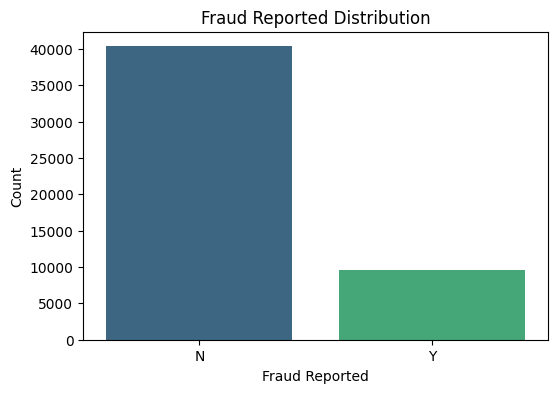

fraud_reported
N    40349
Y     9651
Name: count, dtype: int64


In [6]:
# Fraud Reported Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="fraud_reported",
    palette="viridis"
)

plt.title("Fraud Reported Distribution")
plt.xlabel("Fraud Reported")
plt.ylabel("Count")

plt.show()

print(df["fraud_reported"].value_counts())

### Customer Age Distribution

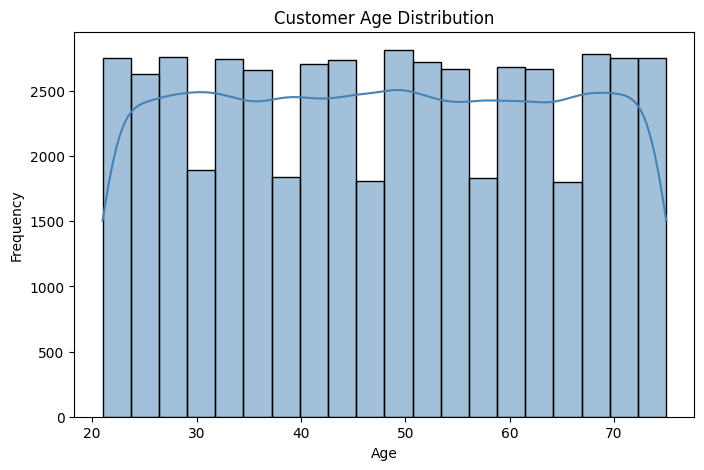

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="customer_age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Claim Amount Distribution

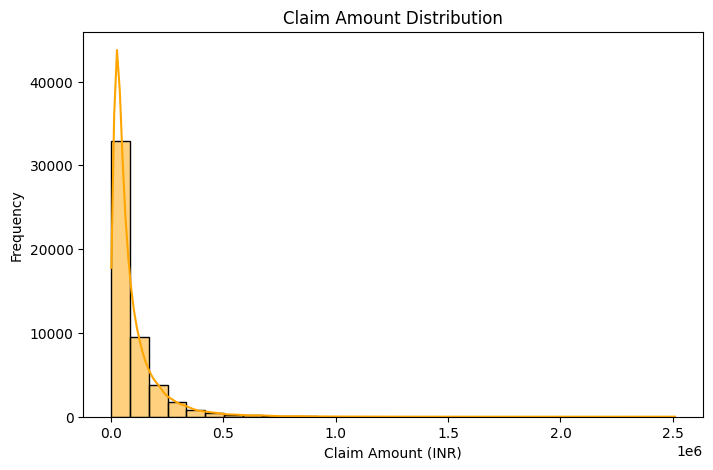

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="claim_amount_inr",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Claim Amount Distribution")
plt.xlabel("Claim Amount (INR)")
plt.ylabel("Frequency")

plt.show()

## Feature Selection

In [7]:
# Remove unnecessary column
df = df.drop("claim_id", axis=1)

# Features and Target
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50000, 16)
Target Shape: (50000,)


## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (40000, 16)
X_test : (10000, 16)


## One-Hot Encoding

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# Fit and transform
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

Preprocessing completed successfully!
X_train Shape: (40000, 40)
X_test Shape : (10000, 40)


## Apply SMOTE

In [11]:
from imblearn.over_sampling import SMOTE

# Convert target labels
y_train = y_train.map({"N": 0, "Y": 1})
y_test = y_test.map({"N": 0, "Y": 1})

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

After SMOTE:
fraud_reported
1    32279
0    32279
Name: count, dtype: int64

X_train Shape: (64558, 40)
y_train Shape: (64558,)


## Build Artificial Neural Network (ANN)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build ANN Model
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the ANN Model

In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("ANN model compiled successfully!")

ANN model compiled successfully!


## Train the ANN Model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7997 - loss: 0.4408 - val_accuracy: 0.8160 - val_loss: 0.4033
Epoch 2/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8268 - loss: 0.3944 - val_accuracy: 0.8103 - val_loss: 0.4088
Epoch 3/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8332 - loss: 0.3848 - val_accuracy: 0.8124 - val_loss: 0.4058
Epoch 4/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8375 - loss: 0.3763 - val_accuracy: 0.8254 - val_loss: 0.4040
Epoch 5/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8401 - loss: 0.3713 - val_accuracy: 0.8394 - val_loss: 0.3774
Epoch 6/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8432 - loss: 0.3660 - val_accuracy: 0.8270 - val_loss: 0.3896
Epoch 7/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8460 - loss: 0.3617 - val_accuracy: 0.8307 - val_loss: 0.3973
Epoch 8/50
2018/2018 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8480 - loss: 0.3572 - 

## ANN Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ANN Performance")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN Performance
-----------------------------------
Accuracy : 0.8411
Precision: 0.5653
Recall   : 0.7653
F1 Score : 0.6502

Confusion Matrix
[[6934 1136]
 [ 453 1477]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      8070
           1       0.57      0.77      0.65      1930

    accuracy                           0.84     10000
   macro avg       0.75      0.81      0.77     10000
weighted avg       0.87      0.84      0.85     10000



## Training vs Validation Loss

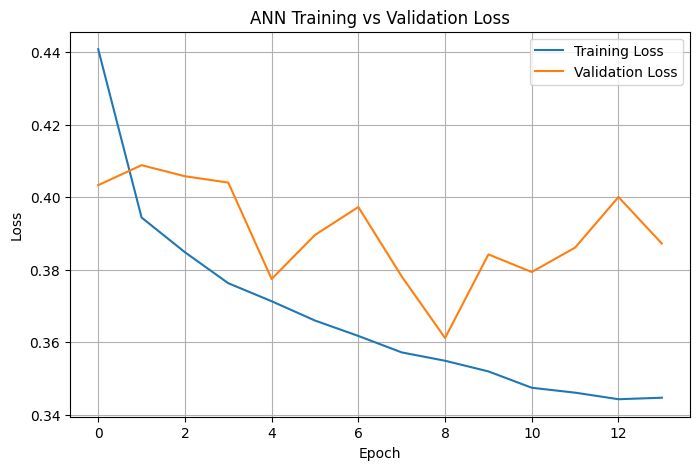

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Training vs Validation Accuracy

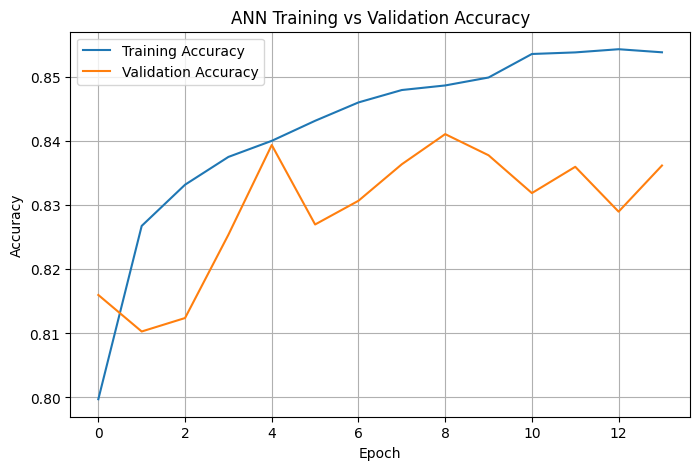

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Save ANN Model

In [20]:
model.save("ann_fraud_detection.keras")

print("ANN model saved successfully!")

ANN model saved successfully!


## Model Comparison

In [21]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "ANN"
    ],
    "Accuracy": [
        0.7945,
        0.8701,
        0.8789,
        0.8411
    ],
    "Precision": [
        0.4792,
        0.7227,
        0.7234,
        0.5653
    ],
    "Recall": [
        0.7451,
        0.5306,
        0.6031,
        0.7653
    ],
    "F1 Score": [
        0.5832,
        0.6119,
        0.6578,
        0.6502
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7945,0.4792,0.7451,0.5832
1,Random Forest,0.8701,0.7227,0.5306,0.6119
2,XGBoost,0.8789,0.7234,0.6031,0.6578
3,ANN,0.8411,0.5653,0.7653,0.6502
